In this notebook, we implement **multi-task classification using supervised approach**. The model is trained using the synthetic dataset. The pre-trained model used here is RoBERTa, but it can also be replaced with DeBERTa or other pre-trained models by updating the variable `MODEL_NAME` below.

# Setting Seeds

Here, we begin by setting the random seeds to ensure reproducibility across different runs.

In [1]:
import random
from transformers import set_seed
import os

import pandas as pd
import numpy as np
import warnings
import ast
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, multilabel_confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from datasets import Dataset

import warnings
warnings.filterwarnings('ignore') 

def set_all_seeds(seed=42):
    """Set seeds for reproducible results"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

# Set all seeds
set_all_seeds(42)

/opt/anaconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Set device

We also set the device to use the GPU if available, for more efficient execution.

In [2]:
if torch.backends.mps.is_available(): 
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using MPS (Apple Silicon GPU)


# Load Data and Data Preparation

After setting up the environment configuration, we import the data into the notebook and perform data preparation. Here, we use the **synthetic data** to train the model. The details of each imported dataset are as follows:
1. `survey_df`: Training data generated using ClaudeAI.
4. `survey_test_df`: Testing data generated using ClaudeAI (separate from training and generated with slight prompt modifications).

These datasets can be replaced with other files, as long as they maintain the same characteristics, column names, and data format.

For the data preparation, we perform the following tasks to clean the dataset:
1. Lowercasing and remove non-alphanumeric characters.
2. Remove noisy responses (fewer than 10 characters).
2. Sort and encode the labels.
3. Split training dataset into training and validation sets.

In [7]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from collections import Counter
import nlpaug.augmenter.word as naw
from collections import defaultdict
import random
import re

### 1. Import clean survey data
survey_df = pd.read_excel('synthetic_data_mixed_labels.xlsx')
survey_test_df = pd.read_excel('synthetic_data_test.xlsx')


### 2. Data Preparation
# a. Student response preprocessing
def text_preprocessing(text):
    # Remove regex (any non-alphanumeric characters) and keeping only letters, numbers, and spaces using regex
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)

    # Lowercasing
    text = text.lower()

    return text

survey_df['student_response'] = survey_df['student_response'].apply(lambda x: text_preprocessing(x))
survey_test_df['student_response'] = survey_test_df['student_response'].apply(lambda x: text_preprocessing(x))

# b. Remove noisy text
filtered_df = survey_df[survey_df['student_response'].str.len()>10].copy()

# c. Sort and clean the label
filtered_df['all_labels'] = filtered_df['all_labels'].apply(lambda x: sorted(x) if isinstance(x, list) else x)
survey_test_df['all_labels'] = survey_test_df['all_labels'].apply(lambda x: sorted(x) if isinstance(x, list) else x)

def clean_and_sort_labels(x):
    # Convert string labels to list
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("[") and x.endswith("]"):
            try:
                x_list = ast.literal_eval(x)
            except:
                x_list = x.strip("[]").split(",")
        else:
            x_list = x.split(",")
    elif isinstance(x, list):
        x_list = x
    else:
        return []

    # Clean, deduplicate, and sort
    cleaned = {str(item).strip().strip("[]\"'") for item in x_list if str(item).strip().strip("[]\"'")}
    return sorted(cleaned, key=str.lower)

filtered_df['all_labels'] = filtered_df['all_labels'].apply(clean_and_sort_labels)
survey_test_df['all_labels'] = survey_test_df['all_labels'].apply(clean_and_sort_labels)


### 3. Encode the labels
# Encode category label
category_map = {"teaching & delivery": 0, "assignment & quiz": 1, "course materials & structure": 2}
filtered_df['category'] = filtered_df['category'].map(category_map)
survey_test_df['category_mixed'] = survey_test_df['category_mixed'].map(category_map)

# Encode appropriateness label
app_map = {"inappropriate": 0, "appropriate": 1}
filtered_df['inappropriate_appropriate'] = filtered_df['inappropriate_appropriate'].map(app_map)
survey_test_df['inappropriate_appropriate'] = survey_test_df['inappropriate_appropriate'].map(app_map)

### 4. Split The Data
from sklearn.model_selection import train_test_split

# Split 1: Split out test set
X_test = survey_test_df['student_response'].copy()
y_binary_test = survey_test_df['inappropriate_appropriate'].copy()
y_category_test = survey_test_df['category_mixed'].copy()

# Split 2: Get train_val portion
X_train_val = filtered_df['student_response'].copy()
y_binary_train_val = filtered_df['inappropriate_appropriate'].copy()
y_category_train_val = filtered_df['category_mixed'].copy()

# Create a combined stratification key for both labels
# This ensures both labels are stratified together
stratify_key = y_binary_train_val.astype(str) + '_' + y_category_train_val.astype(str)

# Split train_val into train and validation (8% validation)
X_train, X_val, y_binary_train, y_binary_val, y_category_train, y_category_val = train_test_split(
    X_train_val, y_binary_train_val, y_category_train_val,
    test_size=0.08, random_state=42, stratify=stratify_key
)

# Create DataFrames
train_df = pd.DataFrame({
    "student_response": X_train.values, 
    "inappropriate_appropriate": y_binary_train.values,
    "category": y_category_train.values
})

val_df = pd.DataFrame({
    "student_response": X_val.values, 
    "inappropriate_appropriate": y_binary_val.values,
    "category": y_category_val.values
})

test_df = pd.DataFrame({
    "student_response": X_test.values, 
    "inappropriate_appropriate": y_binary_test.values,
    "category": y_category_test.values
})

### 5. Check the processing result
# Train label distributions
print("Train set shape:", train_df.shape)
print(f'Train proportion binary label: {Counter(y_binary_train)}')
print(f'Train proportion category label: {Counter(y_category_train)}')
print(f'Train combined label distribution:\n{pd.Series(y_binary_train.astype(str) + "_" + y_category_train.astype(str)).value_counts()}\n')

# Validation label distributions
print("Validation set shape:", val_df.shape)
print(f'Validation proportion binary label: {Counter(y_binary_val)}')
print(f'Validation proportion category label: {Counter(y_category_val)}')
print(f'Validation combined label distribution:\n{pd.Series(y_binary_val.astype(str) + "_" + y_category_val.astype(str)).value_counts()}\n')

# Test label distributions
print("Test set shape:", test_df.shape)
print(f'Test proportion binary label: {Counter(y_binary_test)}')
print(f'Test proportion category label: {Counter(y_category_test)}')
print(f'Test combined label distribution:\n{pd.Series(y_binary_test.astype(str) + "_" + y_category_test.astype(str)).value_counts()}\n')

Train set shape: (621, 3)
Train proportion binary label: Counter({1: 466, 0: 155})
Train proportion category label: Counter({'mixed': 210, 'teaching & delivery': 154, 'course materials & structure': 148, 'assignment & quiz': 109})
Train combined label distribution:
1_mixed                           186
1_course materials & structure    132
0_teaching & delivery             103
1_assignment & quiz                97
1_teaching & delivery              51
0_mixed                            24
0_course materials & structure     16
0_assignment & quiz                12
Name: count, dtype: int64

Validation set shape: (54, 3)
Validation proportion binary label: Counter({1: 40, 0: 14})
Validation proportion category label: Counter({'mixed': 18, 'teaching & delivery': 13, 'course materials & structure': 13, 'assignment & quiz': 10})
Validation combined label distribution:
1_mixed                           16
1_course materials & structure    11
1_assignment & quiz                9
0_teaching & 

# Model Setup

Here, we define the model architecture to perform supervised training for two classification tasks: appropriateness and categorization. The appropriateness and categorization tasks here will be performed as **single-label classification** for each response. 

As mentioned earlier, we are currently using RoBERTa in this notebook, but it can be changed by updating the `MODEL_NAME` variable below.

In [4]:
from datasets import Dataset, Sequence, Value
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
import os

### 1. Load models
MODEL_NAME = "roberta-base"

### 2. Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

### 3. Define model Architecture
class MultitaskModel(nn.Module):
    def __init__(self, base_model_name):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(base_model_name)
        hidden_size = self.roberta.config.hidden_size
        
        # Two classification heads
        self.appropriate_head = nn.Linear(hidden_size, 2)  # Binary classification
        self.category_head = nn.Linear(hidden_size, 3)     # Multi-class classification
        
    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]  # CLS token
        
        app_logits = self.appropriate_head(pooled_output)
        cat_logits = self.category_head(pooled_output)
        
        return type('ModelOutput', (), {
            'app_logits': app_logits, 
            'cat_logits': cat_logits
        })()

multitask_model = MultitaskModel(MODEL_NAME).to(device)

### 4. Freeze transformer layers
def freeze_lower_layers(model, num_layers_to_freeze=8):
    # Freeze embeddings
    for param in model.roberta.embeddings.parameters():
        param.requires_grad = False
    
    # Freeze specified number of encoder layers
    for i in range(num_layers_to_freeze):
        for param in model.roberta.encoder.layer[i].parameters():
            param.requires_grad = False

    print(f"Frozen first {num_layers_to_freeze} layers and embeddings")
    
    # Print number of trainable parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Frozen parameters: {total_params - trainable_params:,}")

# Apply freezing strategy
freeze_lower_layers(multitask_model)

### 5. Create Hugging Face Datasets and Tokenise
def prepare_datasets(train_df, val_df, test_df):
    train_dataset = Dataset.from_pandas(train_df)
    val_dataset = Dataset.from_pandas(val_df)
    test_dataset = Dataset.from_pandas(test_df)

    def tokenize(batch):
        texts = [str(x) for x in batch["student_response"]] 
        return tokenizer(texts, 
                         padding="max_length", 
                         truncation=True, 
                         max_length=256)

    train_dataset = train_dataset.map(tokenize, batched=True)
    val_dataset = val_dataset.map(tokenize, batched=True)
    test_dataset = test_dataset.map(tokenize, batched=True)

    # Define columns to keep
    keep_cols = ["input_ids", "attention_mask", "inappropriate_appropriate", "category", "student_response"]

    train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c not in keep_cols])
    val_dataset = val_dataset.remove_columns([c for c in val_dataset.column_names if c not in keep_cols])
    test_dataset = test_dataset.remove_columns([c for c in test_dataset.column_names if c not in keep_cols])

    # Cast labels to proper types
    train_dataset = train_dataset.cast_column("inappropriate_appropriate", Value("int64"))
    val_dataset = val_dataset.cast_column("inappropriate_appropriate", Value("int64"))
    test_dataset = test_dataset.cast_column("inappropriate_appropriate", Value("int64"))
    
    train_dataset = train_dataset.cast_column("category", Value("int64"))
    val_dataset = val_dataset.cast_column("category", Value("int64"))
    test_dataset = test_dataset.cast_column("category", Value("int64"))

    # Set format for PyTorch
    train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "inappropriate_appropriate", "category"])
    val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "inappropriate_appropriate", "category"])
    test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "inappropriate_appropriate", "category"])
    
    return train_dataset, val_dataset, test_dataset

train_dataset, val_dataset, test_dataset = prepare_datasets(train_df, val_df, test_df)

### 6. Evaluation Metrics 
def compute_metrics_multitask(app_predictions, app_labels, cat_predictions, cat_labels, app_mask=None):
    """
    Compute metrics for both appropriateness and category predictions
    app_mask: mask for which samples should have category predictions evaluated
    """
    # Appropriateness metrics
    app_preds = torch.argmax(app_predictions, dim=1).cpu().numpy()
    app_true = app_labels.cpu().numpy()
    
    app_acc = accuracy_score(app_true, app_preds)
    app_f1 = f1_score(app_true, app_preds, average='binary')
    app_prec = precision_score(app_true, app_preds, average='binary', zero_division=0)
    app_rec = recall_score(app_true, app_preds, average='binary', zero_division=0)
    
    metrics = {
        "app_accuracy": app_acc,
        "app_f1": app_f1,
        "app_precision": app_prec,
        "app_recall": app_rec
    }
    
    # Category metrics (only for appropriate samples)
    if app_mask is not None and app_mask.sum() > 0:
        cat_preds = torch.argmax(cat_predictions[app_mask], dim=1).cpu().numpy()
        cat_true = cat_labels[app_mask].cpu().numpy()
        
        cat_acc = accuracy_score(cat_true, cat_preds)
        cat_f1 = f1_score(cat_true, cat_preds, average='macro', zero_division=0)
        cat_prec = precision_score(cat_true, cat_preds, average='macro', zero_division=0)
        cat_rec = recall_score(cat_true, cat_preds, average='macro', zero_division=0)
        
        metrics.update({
            "cat_accuracy": cat_acc,
            "cat_f1": cat_f1,
            "cat_precision": cat_prec,
            "cat_recall": cat_rec
        })
    else:
        metrics.update({
            "cat_accuracy": None,
            "cat_f1": None,
            "cat_precision": None,
            "cat_recall": None
        })
    
    return metrics

### 7. Class Weighting 
def calculate_class_weights(train_df):
    """Calculate class weights for both tasks"""
    
    # Appropriateness class weights
    app_counts = train_df['inappropriate_appropriate'].value_counts()
    total_app = len(train_df)
    app_weights = {}
    for class_id, count in app_counts.items():
        app_weights[class_id] = total_app / (2 * count) 
    
    # Category class weights (only for appropriate samples)
    appropriate_df = train_df[train_df['inappropriate_appropriate'] == 1]
    if len(appropriate_df) > 0:
        cat_counts = appropriate_df['category'].value_counts()
        total_cat = len(appropriate_df)
        cat_weights = {}
        for class_id, count in cat_counts.items():
            cat_weights[class_id] = total_cat / (len(cat_counts) * count)
    else:
        cat_weights = {0: 1.0, 1: 1.0, 2: 1.0}
    
    # Convert to tensors
    app_weight_tensor = torch.FloatTensor([app_weights.get(i, 1.0) for i in range(2)]).to(device)
    cat_weight_tensor = torch.FloatTensor([cat_weights.get(i, 1.0) for i in range(3)]).to(device)
    
    return app_weight_tensor, cat_weight_tensor

app_weights, cat_weights = calculate_class_weights(train_df)
print(f"Appropriateness class weights: {app_weights}")
print(f"Category class weights: {cat_weights}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Frozen first 8 layers and embeddings
Total parameters: 124,649,477
Trainable parameters: 28,945,925
Frozen parameters: 95,703,552


Casting the dataset: 100%|██████████| 104/104 [00:00<00:00, 55111.51 examples/s]


Appropriateness class weights: tensor([1.9904, 0.6677], device='mps:0')
Category class weights: tensor([1.0690, 1.1232, 0.8516], device='mps:0')


# Training Loop

Below is the training function used to begin the model training loop.

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score
import numpy as np
from tqdm import tqdm
import os
import pandas as pd

def train_multitask_model(
    model, train_dataset, val_dataset, app_class_weights, cat_class_weights,
    learning_rate=2e-5, num_epochs=15, batch_size=16, 
    weight_decay=0.01, warmup_ratio=0.1, patience=5,
    results_dir="./results_multi_task"):
    
    # Create results directory
    os.makedirs(results_dir, exist_ok=True)
    
    # Create data loaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Loss functions with class weights
    app_loss_fn = nn.CrossEntropyLoss(weight=app_class_weights)
    cat_loss_fn = nn.CrossEntropyLoss(weight=cat_class_weights)
    
    # Optimizer and scheduler
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    # Calculate warmup steps
    total_steps = len(train_dataloader) * num_epochs
    warmup_steps = int(warmup_ratio * total_steps)
    scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=warmup_steps)
    
    # Training tracking
    best_val_loss = float('inf')
    patience_counter = 0
    all_metrics = []
    
    print(f"Using device: {device}")
    print(f"Total training steps: {total_steps}, Warmup steps: {warmup_steps}")
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        total_train_loss = 0
        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{num_epochs}")
        
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            app_labels = batch['inappropriate_appropriate'].to(device)
            cat_labels = batch['category'].to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            
            # Compute losses
            app_loss = app_loss_fn(outputs.app_logits, app_labels)
            
            # Category loss only for appropriate samples
            app_mask = (app_labels == 1)
            if app_mask.sum() > 0:
                cat_loss = cat_loss_fn(outputs.cat_logits[app_mask], cat_labels[app_mask])
            else:
                cat_loss = torch.tensor(0.0, device=device)
            
            # Combined loss
            total_loss = app_loss + cat_loss
            
            # Backward pass
            total_loss.backward()
            optimizer.step()
            
            # Update scheduler during warmup
            if scheduler.get_last_lr()[0] < learning_rate:
                scheduler.step()
            
            total_train_loss += total_loss.item()
            progress_bar.set_postfix({
                'loss': total_loss.item(), 
                'app_loss': app_loss.item(),
                'cat_loss': cat_loss.item() if isinstance(cat_loss, torch.Tensor) else 0
            })
        
        avg_train_loss = total_train_loss / len(train_dataloader)
        
        # Validation phase
        model.eval()
        total_val_loss = 0
        all_app_preds, all_app_labels = [], []
        all_cat_preds, all_cat_labels = [], []
        all_app_masks = []
        
        with torch.no_grad():
            for batch in val_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                app_labels = batch['inappropriate_appropriate'].to(device)
                cat_labels = batch['category'].to(device)
                
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                
                # Compute losses
                app_loss = app_loss_fn(outputs.app_logits, app_labels)
                
                app_mask = (app_labels == 1)
                if app_mask.sum() > 0:
                    cat_loss = cat_loss_fn(outputs.cat_logits[app_mask], cat_labels[app_mask])
                else:
                    cat_loss = torch.tensor(0.0, device=device)
                
                total_loss = app_loss + cat_loss
                total_val_loss += total_loss.item()
                
                # Collect predictions for metrics
                all_app_preds.append(outputs.app_logits)
                all_app_labels.append(app_labels)
                all_cat_preds.append(outputs.cat_logits)
                all_cat_labels.append(cat_labels)
                all_app_masks.append(app_mask)
        
        avg_val_loss = total_val_loss / len(val_dataloader)
        
        # Concatenate all predictions and labels
        all_app_preds = torch.cat(all_app_preds, dim=0)
        all_app_labels = torch.cat(all_app_labels, dim=0)
        all_cat_preds = torch.cat(all_cat_preds, dim=0)
        all_cat_labels = torch.cat(all_cat_labels, dim=0)
        all_app_masks = torch.cat(all_app_masks, dim=0)
        
        # Compute metrics
        eval_metrics = compute_metrics_multitask(
            all_app_preds, all_app_labels, 
            all_cat_preds, all_cat_labels, 
            all_app_masks
        )
        
        # Print results
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"Appropriateness | Acc: {eval_metrics['app_accuracy']:.3f}, F1: {eval_metrics['app_f1']:.3f}, "
              f"Precision: {eval_metrics['app_precision']:.3f}, Recall: {eval_metrics['app_recall']:.3f}")
        
        if eval_metrics['cat_accuracy'] is not None:
            print(f"Categorisation | Acc: {eval_metrics['cat_accuracy']:.3f}, F1: {eval_metrics['cat_f1']:.3f}, "
                  f"Precision: {eval_metrics['cat_precision']:.3f}, Recall: {eval_metrics['cat_recall']:.3f}")
        else:
            print("Categorisation | No appropriate samples in validation batch")
        
        # Save metrics
        epoch_metrics = eval_metrics.copy()
        epoch_metrics.update({
            'epoch': epoch + 1,
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss
        })
        all_metrics.append(epoch_metrics)
        
        # Early stopping based on validation loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            
            # Save best model
            torch.save({
                'model_state_dict': model.state_dict(),
                'tokenizer': tokenizer,
                'epoch': epoch + 1,
                'val_loss': avg_val_loss,
                'metrics': eval_metrics
            }, f"{results_dir}/best_multitask_model.pt")
            print(f"New best model saved.\n")
        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}\n")
            
            if patience_counter >= patience:
                print(f"Early stopping triggered.\n")
                break
    
    # Create training history dataframe
    history_df = pd.DataFrame(all_metrics)
    history_df = history_df[["epoch", "train_loss", "val_loss"] + 
                           [c for c in history_df.columns if c not in ["epoch", "train_loss", "val_loss"]]]
    
    return history_df, best_val_loss

In [6]:
# Train the cascaded model
training_history_df, best_loss = train_multitask_model(
        multitask_model, train_dataset, val_dataset, 
        app_weights, cat_weights,
        learning_rate=2e-5,
        num_epochs=15,
        batch_size=16,
        patience=5
    )

print(f"Training completed. Best validation loss: {best_loss:.4f}")

# Display training history
training_history_df

Using device: mps
Total training steps: 585, Warmup steps: 58


Epoch 1/15: 100%|██████████| 39/39 [01:12<00:00,  1.86s/it, loss=1.77, app_loss=0.679, cat_loss=1.1] 


Train Loss: 1.8130 | Val Loss: 1.7680
Appropriateness | Acc: 0.796, F1: 0.845, Precision: 1.000, Recall: 0.732
Categorisation | Acc: 0.317, F1: 0.308, Precision: 0.378, Recall: 0.334
New best model saved.



Epoch 2/15: 100%|██████████| 39/39 [01:10<00:00,  1.81s/it, loss=1.54, app_loss=0.452, cat_loss=1.08]


Train Loss: 1.7009 | Val Loss: 1.4842
Appropriateness | Acc: 1.000, F1: 1.000, Precision: 1.000, Recall: 1.000
Categorisation | Acc: 0.512, F1: 0.493, Precision: 0.643, Recall: 0.530
New best model saved.



...

Epoch 14/15: 100%|██████████| 39/39 [01:21<00:00,  2.09s/it, loss=0.236, app_loss=0.00416, cat_loss=0.232] 


Train Loss: 0.2798 | Val Loss: 0.6596
Appropriateness | Acc: 1.000, F1: 1.000, Precision: 1.000, Recall: 1.000
Categorisation | Acc: 0.683, F1: 0.686, Precision: 0.686, Recall: 0.686
New best model saved.



Epoch 15/15: 100%|██████████| 39/39 [01:12<00:00,  1.86s/it, loss=0.218, app_loss=0.0124, cat_loss=0.206]   


Train Loss: 0.2520 | Val Loss: 0.7801
Appropriateness | Acc: 1.000, F1: 1.000, Precision: 1.000, Recall: 1.000
Categorisation | Acc: 0.683, F1: 0.688, Precision: 0.704, Recall: 0.689
No improvement. Patience: 1/5

Training completed. Best validation loss: 0.6596


,epoch,train_loss,val_loss,app_accuracy,app_f1,app_precision,app_recall,cat_accuracy,cat_f1,cat_precision,cat_recall
0,1,1.813001,1.768013,0.796296,0.84507,1.0,0.731707,0.317073,0.308081,0.377778,0.333868
1,2,1.700908,1.484186,1.000000,1.00000,1.0,1.000000,0.512195,0.492899,0.642693,0.529915
2,3,1.192685,0.939963,1.000000,1.00000,1.0,1.000000,0.487805,0.473064,0.537037,0.505342
3,4,0.847766,0.843124,1.000000,1.00000,1.0,1.000000,0.609756,0.598380,0.621212,0.602564
4,5,0.725333,0.813235,1.000000,1.00000,1.0,1.000000,0.536585,0.545752,0.599206,0.552350
5,6,0.629715,0.778596,1.000000,1.00000,1.0,1.000000,0.585366,0.593615,0.608333,0.584402
6,7,0.583511,0.795548,1.000000,1.00000,1.0,1.000000,0.585366,0.566634,0.579545,0.576923
7,8,0.516828,0.711587,1.000000,1.00000,1.0,1.000000,0.682927,0.682713,0.680342,0.686432
8,9,0.483770,0.772023,1.000000,1.00000,1.0,1.000000,0.658537,0.668019,0.702339,0.661325
9,10,0.442798,0.702643,1.000000,1.00000,1.0,1.000000,0.658537,0.665873,0.684641,0.663462


# Analysis

We use this to quickly analyze the training results and effectively assess the trained model performance.

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix, multilabel_confusion_matrix
import seaborn as sns
import pandas as pd
import torch.nn as nn
import os
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

def plot_multitask_training_curves(training_history_df):

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('Multitask Model Training Progress', fontsize=16, fontweight='bold')

    epochs = training_history_df['epoch'].values
    train_loss = training_history_df['train_loss'].values
    val_loss = training_history_df['val_loss'].values

    # Loss curves (top-left)
    axes[0, 0].plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=2)
    axes[0, 0].plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Appropriateness metrics (top-right)
    app_accuracy = training_history_df['app_accuracy'].values
    app_f1 = training_history_df['app_f1'].values
    app_precision = training_history_df['app_precision'].values
    app_recall = training_history_df['app_recall'].values

    axes[0, 1].plot(epochs, app_accuracy, 'g-', label='Accuracy', linewidth=2)
    axes[0, 1].plot(epochs, app_f1, 'b-', label='F1 Score', linewidth=2)
    axes[0, 1].plot(epochs, app_precision, 'orange', label='Precision', linewidth=2)
    axes[0, 1].plot(epochs, app_recall, 'red', label='Recall', linewidth=2)
    axes[0, 1].set_title('Appropriateness Classification Metrics')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Score')
    axes[0, 1].legend()
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].grid(True, alpha=0.3)

    # Category metrics (bottom-left)
    cat_accuracy = training_history_df['cat_accuracy'].fillna(0).values
    cat_f1 = training_history_df['cat_f1'].fillna(0).values
    cat_precision = training_history_df['cat_precision'].fillna(0).values
    cat_recall = training_history_df['cat_recall'].fillna(0).values

    valid_epochs = epochs[cat_accuracy > 0] if np.any(cat_accuracy > 0) else epochs
    valid_cat_acc = cat_accuracy[cat_accuracy > 0] if np.any(cat_accuracy > 0) else cat_accuracy
    valid_cat_f1 = cat_f1[cat_f1 > 0] if np.any(cat_f1 > 0) else cat_f1
    valid_cat_prec = cat_precision[cat_precision > 0] if np.any(cat_precision > 0) else cat_precision
    valid_cat_rec = cat_recall[cat_recall > 0] if np.any(cat_recall > 0) else cat_recall

    if len(valid_epochs) > 0 and np.any(valid_cat_acc > 0):
        axes[1, 0].plot(valid_epochs, valid_cat_acc, 'g-', label='Accuracy', linewidth=2)
        axes[1, 0].plot(valid_epochs, valid_cat_f1, 'b-', label='F1 Score', linewidth=2)
        axes[1, 0].plot(valid_epochs, valid_cat_prec, 'orange', label='Precision', linewidth=2)
        axes[1, 0].plot(valid_epochs, valid_cat_rec, 'red', label='Recall', linewidth=2)
    
    axes[1, 0].set_title('Category Classification Metrics')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].legend()
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].grid(True, alpha=0.3)

    # Combined metrics (bottom-right)
    axes[1, 1].plot(epochs, app_f1, 'b-', label='Appropriateness F1', linewidth=2)
    if len(valid_epochs) > 0 and np.any(valid_cat_f1 > 0):
        axes[1, 1].plot(valid_epochs, valid_cat_f1, 'r-', label='Category F1', linewidth=2)
    axes[1, 1].set_title('Combined F1 Scores')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('F1 Score')
    axes[1, 1].legend()
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def get_multitask_predictions(model, test_dataloader, device):
    """
    Get predictions from multitask model
    Returns both appropriateness and category predictions
    """
    model.eval()
    
    all_app_logits, all_app_labels = [], []
    all_cat_logits, all_cat_labels = [], []
    all_app_probs = []

    with torch.no_grad():
        for batch in test_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            app_labels = batch['inappropriate_appropriate'].to(device)
            cat_labels = batch['category'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            
            app_logits = outputs.app_logits
            cat_logits = outputs.cat_logits
            app_probs = torch.softmax(app_logits, dim=1)

            # Collect outputs
            all_app_logits.append(app_logits.cpu())
            all_app_labels.append(app_labels.cpu())
            all_cat_logits.append(cat_logits.cpu())
            all_cat_labels.append(cat_labels.cpu())
            all_app_probs.append(app_probs.cpu())

    # Stack results
    app_logits = torch.cat(all_app_logits, dim=0).numpy()
    app_true = torch.cat(all_app_labels, dim=0).numpy()
    cat_logits = torch.cat(all_cat_logits, dim=0).numpy()
    cat_true = torch.cat(all_cat_labels, dim=0).numpy()
    app_probs = torch.cat(all_app_probs, dim=0).numpy()

    # Get predictions
    app_pred = np.argmax(app_logits, axis=1)
    cat_pred = np.argmax(cat_logits, axis=1)

    return app_pred, app_true, app_logits, cat_pred, cat_true, cat_logits, app_probs

def plot_multitask_confusion_matrices(app_true, app_pred, cat_true, cat_pred, class_names):

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Appropriateness confusion matrix
    cm_app = confusion_matrix(app_true, app_pred)
    sns.heatmap(cm_app, annot=True, fmt='d', cmap='Blues', ax=axes[0],
               xticklabels=['Inappropriate', 'Appropriate'],
               yticklabels=['Inappropriate', 'Appropriate'])
    axes[0].set_title('Appropriateness Classification')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    
    # Category confusion matrix 
    app_mask = (app_true == 1)  # Only appropriate samples
    if app_mask.sum() > 0:
        cat_true_filtered = cat_true[app_mask]
        cat_pred_filtered = cat_pred[app_mask]
        
        cm_cat = confusion_matrix(cat_true_filtered, cat_pred_filtered)
        sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                   xticklabels=class_names,
                   yticklabels=class_names)
        axes[1].set_title('Category Classification (Appropriate Samples Only)')
    else:
        axes[1].text(0.5, 0.5, 'No appropriate samples\nin test set', 
                    ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('Category Classification')
    
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    
    plt.suptitle('Multitask Model Confusion Matrices', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_multitask_confidence_distributions(app_logits, app_true, cat_logits, cat_true, class_names):
 
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Appropriateness confidence distribution
    app_probs = torch.softmax(torch.tensor(app_logits), dim=1).numpy()[:, 1]  # Probability of appropriate
    
    appropriate_probs = app_probs[app_true == 1]
    inappropriate_probs = app_probs[app_true == 0]
    
    axes[0].hist(inappropriate_probs, bins=20, alpha=0.7, color='red',
                label='Inappropriate (True)', edgecolor='black')
    axes[0].hist(appropriate_probs, bins=20, alpha=0.7, color='green',
                label='Appropriate (True)', edgecolor='black')
    axes[0].axvline(x=0.5, color='black', linestyle='--', label='Threshold')
    axes[0].set_title('Appropriateness Confidence Distribution')
    axes[0].set_xlabel('Confidence Score (Appropriate)')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Category confidence distribution (only for appropriate samples)
    app_mask = (app_true == 1)
    if app_mask.sum() > 0:
        cat_probs = torch.softmax(torch.tensor(cat_logits[app_mask]), dim=1).numpy()
        cat_true_filtered = cat_true[app_mask]
        
        # Plot max confidence for each sample
        max_confidence = np.max(cat_probs, axis=1)
        cat_pred_filtered = np.argmax(cat_probs, axis=1)
        
        correct_mask = (cat_pred_filtered == cat_true_filtered)
        correct_conf = max_confidence[correct_mask]
        incorrect_conf = max_confidence[~correct_mask]
        
        axes[1].hist(incorrect_conf, bins=20, alpha=0.7, color='red',
                    label='Incorrect', edgecolor='black')
        axes[1].hist(correct_conf, bins=20, alpha=0.7, color='green',
                    label='Correct', edgecolor='black')
        axes[1].set_title('Category Classification Confidence')
        axes[1].set_xlabel('Max Confidence Score')
        axes[1].set_ylabel('Frequency')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'No appropriate samples\nfor category analysis', 
                    ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('Category Classification Confidence')
    
    plt.suptitle('Multitask Model Confidence Distributions', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def print_multitask_comprehensive_report(app_true, app_pred, cat_true, cat_pred, class_names):

    print("\nAppropriateness Classification Report:")
    print(classification_report(app_true, app_pred, 
                              target_names=['Inappropriate', 'Appropriate'], digits=4))
    
    # Category classification (only for appropriate samples)
    app_mask = (app_true == 1)
    if app_mask.sum() > 0:
        cat_true_filtered = cat_true[app_mask]
        cat_pred_filtered = cat_pred[app_mask]
        
        print(f"\nCategory Classification Report (Appropriate Samples Only, n={app_mask.sum()}):")
        print(classification_report(cat_true_filtered, cat_pred_filtered, 
                                  target_names=class_names, digits=4))
    else:
        print("\nCategory Classification Report: No appropriate samples in test set")

def visualize_multitask_training_results(model, dataset, 
                                       training_history_df, device, batch_size=8):

    class_names = ["assignment & quiz", "course materials & structure", "teaching & delivery"]

    # Create test dataloader
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # Get predictions
    (app_pred, app_true, app_logits,
     cat_pred, cat_true, cat_logits, app_probs) = get_multitask_predictions(
        model, dataloader, device)
    
    # Create all visualizations
    plot_multitask_training_curves(training_history_df)
    
    plot_multitask_confusion_matrices(app_true, app_pred, cat_true, cat_pred, class_names)
    
    plot_multitask_confidence_distributions(app_logits, app_true, cat_logits, cat_true, class_names)
    
    print_multitask_comprehensive_report(app_true, app_pred, cat_true, cat_pred, class_names)

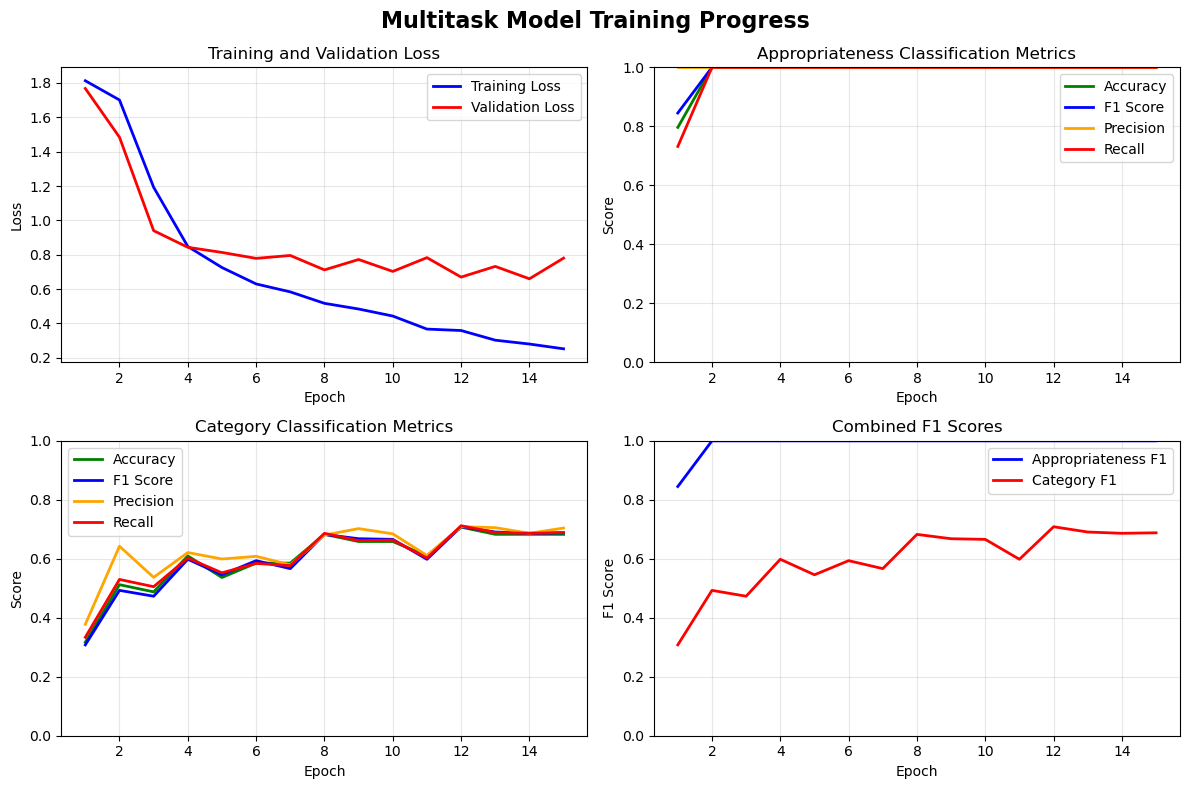

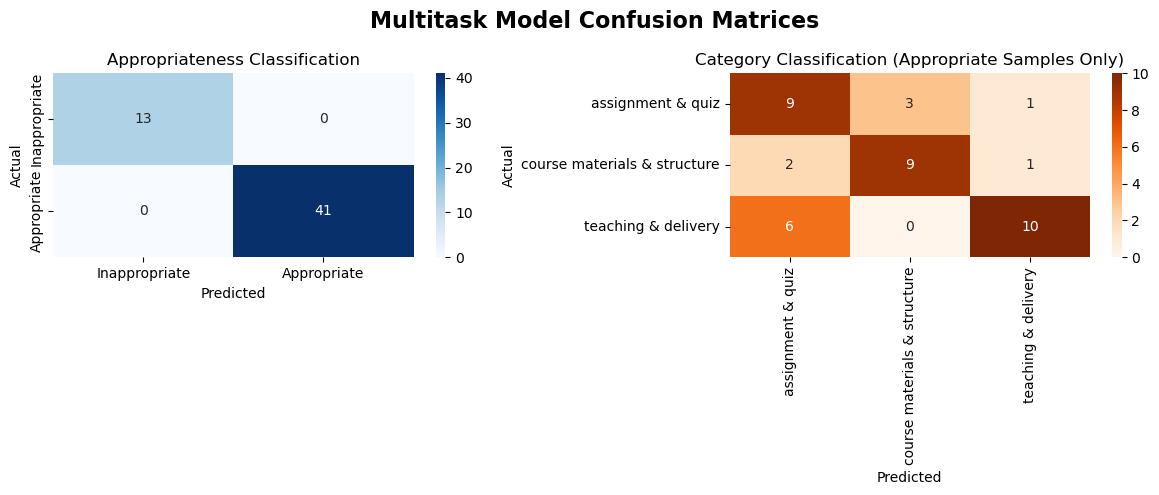

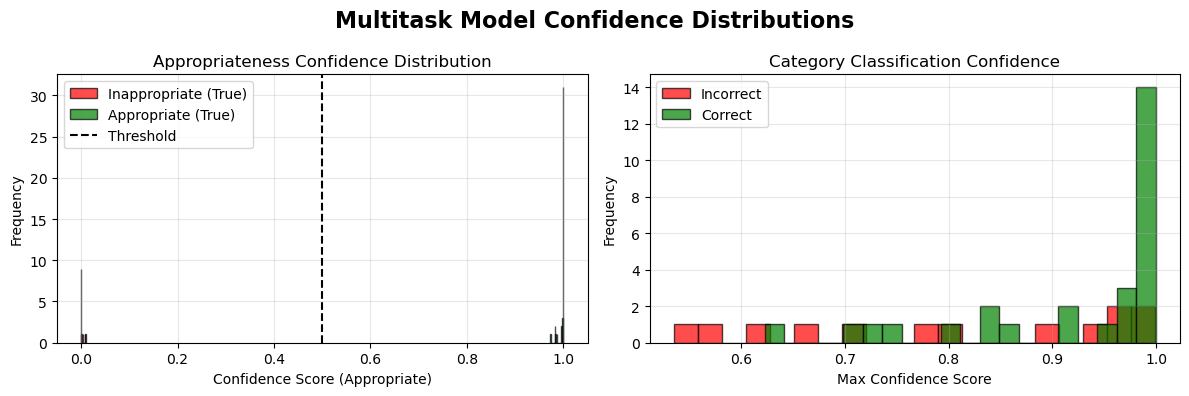


Appropriateness Classification Report:
               precision    recall  f1-score   support

Inappropriate     1.0000    1.0000    1.0000        13
  Appropriate     1.0000    1.0000    1.0000        41

     accuracy                         1.0000        54
    macro avg     1.0000    1.0000    1.0000        54
 weighted avg     1.0000    1.0000    1.0000        54


Category Classification Report (Appropriate Samples Only, n=41):
                              precision    recall  f1-score   support

           assignment & quiz     0.5294    0.6923    0.6000        13
course materials & structure     0.7500    0.7500    0.7500        12
         teaching & delivery     0.8333    0.6250    0.7143        16

                    accuracy                         0.6829        41
                   macro avg     0.7042    0.6891    0.6881        41
                weighted avg     0.7126    0.6829    0.6885        41



In [14]:
visualize_multitask_training_results(
    model=multitask_model,
    dataset=val_dataset,
    training_history_df=training_history_df,
    device=device,
    batch_size=8
)

# Testing Model

Here, we test the model using the testing dataset to evaluate its performance on new, unseen data. We begin by loading the pretrained model that was automatically saved during training and then use it to generate labels for the testing set.

In [6]:
import os
import numpy as np
import torch
from transformers import AutoTokenizer
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

def load_multitask_model(results_dir="./results_multi_task", 
                        model_name="roberta-base",
                        device=None):

    model_path = os.path.join(results_dir, "best_multitask_model.pt")
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Multitask model not found at: {model_path}")
    
    print(f"Loading multitask model from: {results_dir}")
    print(f"Using device: {device}")

    # Load model checkpoint
    checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)
    
    # Initialize model
    model = MultitaskModel(model_name)
    
    # Load trained weights
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Move model to device  
    model.to(device)
    model.eval()
    
    # Load tokenizer from checkpoint or fallback to HuggingFace
    if 'tokenizer' in checkpoint:
        tokenizer = checkpoint['tokenizer']
    else:
        from transformers import AutoTokenizer
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    
    print("Multitask model loaded successfully.")
    print(f"Best validation loss: {checkpoint.get('val_loss', 'N/A')}")
    
    return model, tokenizer

def predict_with_multitask_model(model, tokenizer, texts, 
                                app_labels=None, cat_labels=None,
                                device=None, batch_size=8):

    model.eval()
    
    all_app_predictions = []
    all_cat_predictions = []
    all_app_probs = []
    all_cat_probs = []
    
    # Process in batches
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenize batch
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors='pt',
            max_length=256
        )
        
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        
        with torch.no_grad():
            # Get predictions
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            
            app_logits = outputs.app_logits
            cat_logits = outputs.cat_logits
            
            app_probs = torch.softmax(app_logits, dim=1)
            cat_probs = torch.softmax(cat_logits, dim=1)
            
            app_preds = torch.argmax(app_logits, dim=1)
            cat_preds = torch.argmax(cat_logits, dim=1)
            
            # Store predictions
            all_app_predictions.extend(app_preds.cpu().numpy())
            all_cat_predictions.extend(cat_preds.cpu().numpy())
            all_app_probs.extend(app_probs.cpu().numpy())
            all_cat_probs.extend(cat_probs.cpu().numpy())
    
    results = {
        'app_predictions': all_app_predictions,
        'cat_predictions': all_cat_predictions,
        'app_probabilities': all_app_probs,
        'cat_probabilities': all_cat_probs
    }
    
    # Compute metrics if labels are provided
    if app_labels is not None:
        from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
        
        app_acc = accuracy_score(app_labels, all_app_predictions)
        app_f1 = f1_score(app_labels, all_app_predictions, average='binary')
        app_prec = precision_score(app_labels, all_app_predictions, average='binary', zero_division=0)
        app_rec = recall_score(app_labels, all_app_predictions, average='binary', zero_division=0)
        
        print("Appropriateness Classification Metrics:")
        print(f"Accuracy: {app_acc:.4f}")
        print(f"F1: {app_f1:.4f}")
        print(f"Precision: {app_prec:.4f}")
        print(f"Recall: {app_rec:.4f}")
        
        results['app_metrics'] = {
            'accuracy': app_acc,
            'f1': app_f1,
            'precision': app_prec,
            'recall': app_rec
        }
    
    if cat_labels is not None and app_labels is not None:

        # Only evaluate category predictions for appropriate samples
        app_mask = np.array(app_labels) == 1
        if app_mask.sum() > 0:
            cat_true_filtered = np.array(cat_labels)[app_mask]
            cat_pred_filtered = np.array(all_cat_predictions)[app_mask]
            
            cat_acc = accuracy_score(cat_true_filtered, cat_pred_filtered)
            cat_f1 = f1_score(cat_true_filtered, cat_pred_filtered, average='macro', zero_division=0)
            cat_prec = precision_score(cat_true_filtered, cat_pred_filtered, average='macro', zero_division=0)
            cat_rec = recall_score(cat_true_filtered, cat_pred_filtered, average='macro', zero_division=0)
            
            print(f"\nCategory Classification Metrics (n={app_mask.sum()} appropriate samples):")
            print(f"Accuracy: {cat_acc:.4f}")
            print(f"F1 Macro: {cat_f1:.4f}")
            print(f"Precision Macro: {cat_prec:.4f}")
            print(f"Recall Macro: {cat_rec:.4f}")
            
            results['cat_metrics'] = {
                'accuracy': cat_acc,
                'f1': cat_f1,
                'precision': cat_prec,
                'recall': cat_rec
            }
        else:
            print("\nCategory Classification Metrics: No appropriate samples found")
            results['cat_metrics'] = None
    
    return results


In [7]:
# Load the pre-trained model
multi_task_model, tokenizer = load_multitask_model(
    results_dir="./results_multi_task",
    model_name="roberta-base",
    device=device
)


Loading multitask model from: ./results_multi_task
Using device: mps


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Multitask model loaded successfully.
Best validation loss: 0.6596477441489697


In [22]:
# Evaluate the prediction result using new, unseen data
results = predict_with_multitask_model(
    multi_task_model, tokenizer,
    texts=X_test.tolist(),
    app_labels=y_binary_test,
    cat_labels=y_category_test,
    device=device
)

Appropriateness Classification Metrics:
Accuracy: 1.0000
F1: 1.0000
Precision: 1.0000
Recall: 1.0000

Category Classification Metrics (n=73 appropriate samples):
Accuracy: 0.7397
F1 Macro: 0.7344
Precision Macro: 0.7514
Recall Macro: 0.7351
